In [22]:
# Libraries
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
games = pd.read_csv("../data/processed/game_lifecycle_clean.csv")

games.head()

,app_id,title,launch_price,reviews_total,review_score,tags,baseline_players,relative_6m,relative_12m,relative_24m
0,10,Counter-Strike,9.99,137421,0.97,"Action, FPS, Multiplayer, Shooter, Classic, Te...",32222.520000,0.936222,0.633616,0.560820
1,20,Team Fortress Classic,4.99,5475,0.85,"Action, FPS, Multiplayer, Classic, Hero Shoote...",91.676667,0.886740,0.748027,0.702214
2,30,Day of Defeat,4.99,3692,0.87,"FPS, World War II, Multiplayer, Shooter, Actio...",308.633333,0.992623,0.679015,0.624355
3,40,Deathmatch Classic,4.99,1923,0.80,"Action, FPS, Classic, Multiplayer, Shooter, Fi...",7.426667,0.828546,0.583932,0.425494
4,50,Half-Life: Opposing Force,4.99,15498,0.95,"FPS, Action, Classic, Sci fi, Singleplayer, Sh...",63.696667,0.664556,0.632268,0.774295


In [24]:
games.info()

<class 'pandas.DataFrame'>
RangeIndex: 2798 entries, 0 to 2797
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   app_id            2798 non-null   int64  
 1   title             2798 non-null   str    
 2   launch_price      2798 non-null   float64
 3   reviews_total     2798 non-null   int64  
 4   review_score      2798 non-null   float64
 5   tags              2798 non-null   str    
 6   baseline_players  2798 non-null   float64
 7   relative_6m       2798 non-null   float64
 8   relative_12m      2798 non-null   float64
 9   relative_24m      2798 non-null   float64
dtypes: float64(6), int64(2), str(2)
memory usage: 218.7 KB


## Lifecycle Categories
Declining: Relative24 < 0.5

Sustained: 0.5 ≤ Relative24 ≤ 1

Growing: Relative24 > 1

### Definition
Declining: activity after two years is less than half the early baseline.
Sustained: retains at least half of the early baseline.
Growing: has exceeded its early baseline after two years.

In [25]:
def classify_lifecycle(relative_activity):
    if relative_activity < 0.5:
        return "Declining"
    elif relative_activity <= 1:
        return "Sustained"
    else:
        return "Growing"


games["lifecycle_category"] = (games["relative_24m"].apply(classify_lifecycle))

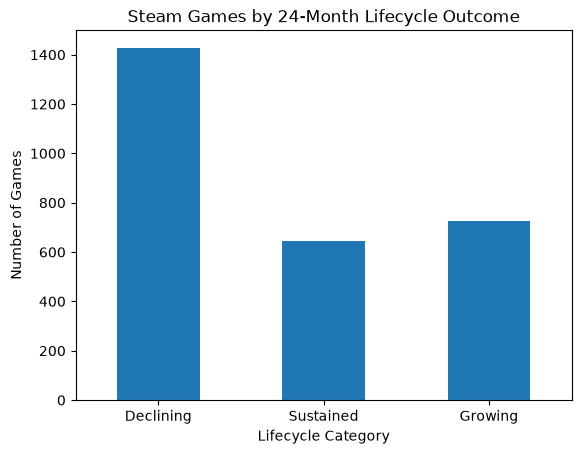

In [26]:
order = ["Declining", "Sustained", "Growing"]

category_counts = (
    games["lifecycle_category"]
    .value_counts()
    .reindex(order)
)

category_counts.plot(kind="bar")

plt.xlabel("Lifecycle Category")
plt.ylabel("Number of Games")
plt.title("Steam Games by 24-Month Lifecycle Outcome")
plt.xticks(rotation=0)

plt.show()

In [27]:
games.to_csv("../data/processed/game_lifecycle_classified.csv", index=False)